# Práctica 6 — Airzbe Cruz

**Dataset:** 30,005 clientes de tarjeta de crédito en Taiwán. Variable objetivo
`default payment next month` (1 = incumplió el pago, 0 = no incumplió).
Se esta utilizando Python por ende sed muestra una tabla de equivalencias

| RapidMiner | Python |
|---|---|
| Retrieve | `pd.read_csv()` |
| Set Role (Label) | separar `X` (atributos) / `y` (variable objetivo) |
| Split Data | `train_test_split()` |
| k-Nearest Neighbors | `KNeighborsClassifier()` |
| Naive Bayes | `GaussianNB()` |
| Apply Model | `.predict()` / `.predict_proba()` |
| Performance (Binomial) | `accuracy_score`, `confusion_matrix`, `roc_auc_score` |


In [ ]:
# Análisis y manipulación de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y selección de modelos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Algoritmos de clasificación
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Métricas de evaluación
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

# Configuración de estilo global para gráficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

# PARTE I
El archivo CSV contiene primero los encabezados genéricos `X1…Y` y en la primera fila, los nombres reales (`LIMIT_BAL`, `SEX`, …). Por ello, esa primera fila se promueve a encabezado.


In [ ]:
import pandas as pd

try:
    from google.colab import files

    uploaded = files.upload()  # selecciona ccdefault.csv desde tu computadora
    archivo_csv = next(iter(uploaded))
except ImportError:
    archivo_csv = "ccdefault.csv"

df_raw = pd.read_csv(archivo_csv, dtype=str)
print("Dimensión original:", df_raw.shape)
df_raw.head(3)

Saving ccdefault.csv to ccdefault.csv
Dimensión original: (30006, 25)


,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1


### 1.1. Formato de datos: Header y Start Row

El equivalente de **Header = 1** y **Start Row = 1** consiste en promover la primera fila a nombres de columna y comenzar los registros en la fila siguiente.

In [ ]:
if "Y" in df_raw.columns and str(df_raw.iloc[0]["Y"]).lower().startswith("default"):
    nombres_reales = df_raw.iloc[0].astype(str).str.strip().tolist()
    df = df_raw.iloc[1:].copy()
    df.columns = nombres_reales
else:
    df = df_raw.copy()

df = df.rename(columns={"default payment next month": "default"})

# esto porque las variables del archivo representan valores numéricos.
for columna in df.columns:
    df[columna] = pd.to_numeric(df[columna], errors="coerce")

df = df[df["default"].isin([0, 1])].copy()

print("Dimensión después de promover el encabezado:", df.shape)
print("Duplicados completos:", df.duplicated().sum())
print("Valores faltantes:", int(df.isna().sum().sum()))
df.head()

Dimensión después de promover el encabezado: (30005, 25)
Duplicados completos: 0
Valores faltantes: 0


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
1,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
5,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


### 1.2. Formato de columnas: variable binomial y rol Label

Como se tiene el rol *Label* , para documentar el tipo marco como categóricas en el DataFrame de trabajo.


In [ ]:
cat_cols = ["SEX", "EDUCATION", "MARRIAGE"]
for c in cat_cols:
    df[c] = df[c].astype("category")

df["default"] = df["default"].astype("category")

print("Clases de la variable objetivo:", list(df["default"].cat.categories))
print(df.dtypes)

Clases de la variable objetivo: [0, 1]
ID              int64
LIMIT_BAL       int64
SEX          category
EDUCATION    category
MARRIAGE     category
AGE             int64
PAY_0           int64
PAY_2           int64
PAY_3           int64
PAY_4           int64
PAY_5           int64
PAY_6           int64
BILL_AMT1       int64
BILL_AMT2       int64
BILL_AMT3       int64
BILL_AMT4       int64
BILL_AMT5       int64
BILL_AMT6       int64
PAY_AMT1        int64
PAY_AMT2        int64
PAY_AMT3        int64
PAY_AMT4        int64
PAY_AMT5        int64
PAY_AMT6        int64
default      category
dtype: object


### 1.3. Guardar en la carpeta de datos del repositorio local

In [ ]:
import os
os.makedirs("Datos", exist_ok=True)
ruta_limpia = "Datos/ccdefault_limpio.csv"
df.to_csv(ruta_limpia, index=False)
print("Archivo guardado en:", ruta_limpia)

Archivo guardado en: Datos/ccdefault_limpio.csv


## 2. Retrieve: recuperar el archivo guardado

El equivalente de **Retrieve** es volver a leer el archivo limpio desde `Datos/`.

In [ ]:
datos = pd.read_csv(ruta_limpia)
print("Datos recuperados:", datos.shape)
datos.head()

Datos recuperados: (30005, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 3. Set Role: definir `default` como Label

In [ ]:
ID = datos["ID"].astype(int)
X = datos.drop(columns=["ID", "default"]).apply(pd.to_numeric)
y = datos["default"].astype(int)

feature_cols = X.columns.tolist()
print("Variable objetivo (Label): default")
print("Predictores:", len(feature_cols))
print("Distribución de clases:")
display(y.value_counts().sort_index().rename(index={0: "No default", 1: "Default"}).to_frame("Frecuencia"))
display((y.value_counts(normalize=True).sort_index() * 100).round(2).to_frame("Porcentaje"))

Variable objetivo (Label): default
Predictores: 23
Distribución de clases:


,Frecuencia
default,
No default,23359
Default,6646


,Porcentaje
default,
0,77.85
1,22.15


## 4. Split Data (70% training / 30% testing)
*Split Data* con particiones 0.70 / 0.30 es el equivalente.

Uso `stratify=y` para que ambas particiones conserven la misma proporción
de clases (≈78% no-default / 22% default)  porque el dataset está
desbalanceado y una partición aleatoria simple podría dejar muy
pocos casos de la clase minoritaria en el conjunto de prueba.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
print("Entrenamiento:", X_train.shape, "| Prueba:", X_test.shape)
print("Default entrenamiento:", round(y_train.mean() * 100, 2), "%")
print("Default prueba:", round(y_test.mean() * 100, 2), "%")

Entrenamiento: (21003, 23) | Prueba: (9002, 23)
Default entrenamiento: 22.15 %
Default prueba: 22.15 %


## 5.Algoritmo k-Nearest Neighbors (k-NN)
*k-Nearest Neighbors* es el equivalente con valores por defecto (k=5).

Se tiene que estandarizar antes de k-NN.

k-NN clasifica según la **distancia Euclidiana** a los vecinos más cercanos. Si no estandarizamos,una variable con escala grande dominaría el cálculo de distancia sobre variables con escala pequeña el mismo problema de escalas.


In [ ]:
from sklearn.pipeline import Pipeline

knn = Pipeline([
    ("escalado", StandardScaler()),
    ("modelo", KNeighborsClassifier())  # n_neighbors=5 por defecto
])

knn.fit(X_train, y_train)

Pipeline(steps=[('escalado', StandardScaler()),
                ('modelo', KNeighborsClassifier())])

## 6. Apply Model: aplicar el modelo al conjunto de prueba

 *Apply Model* (conecta el modelo entrenado con el conjunto de prueba no etiquetado y genera las predicciones).


In [ ]:
y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)[:, 1]

comparacion_knn = pd.DataFrame({
    "ID": datos.loc[X_test.index, "ID"].astype(int),
    "Real": y_test,
    "Prediccion": y_pred_knn,
    "Probabilidad_default": y_prob_knn
}).reset_index(drop=True)

comparacion_knn.head(10)

,ID,Real,Prediccion,Probabilidad_default
0,8943,0,0,0.2
1,22920,0,0,0.2
2,11393,1,0,0.4
3,5803,0,0,0.4
4,4423,0,0,0.0
5,2444,0,0,0.0
6,13707,0,0,0.0
7,18645,0,0,0.0
8,8499,0,0,0.2
9,16890,1,1,0.8


## 7. Performance (Binominal): Accuracy, Classification Error y AUC

In [ ]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluar_modelo(nombre, y_real, y_pred, y_prob):
    accuracy = accuracy_score(y_real, y_pred)
    resultado = {
        "Modelo": nombre,
        "Accuracy": accuracy,
        "Classification Error": 1 - accuracy,
        "AUC": roc_auc_score(y_real, y_prob),
        "Balanced Accuracy": balanced_accuracy_score(y_real, y_pred),
        "Precision clase 1": precision_score(y_real, y_pred, zero_division=0),
        "Recall clase 1": recall_score(y_real, y_pred, zero_division=0),
        "F1 clase 1": f1_score(y_real, y_pred, zero_division=0),
    }
    return resultado

metricas_knn = evaluar_modelo("k-NN 70/30", y_test, y_pred_knn, y_prob_knn)
display(pd.DataFrame([metricas_knn]).set_index("Modelo").round(4))

,Accuracy,Classification Error,AUC,Balanced Accuracy,Precision clase 1,Recall clase 1,F1 clase 1
Modelo,,,,,,,
k-NN 70/30,0.7908,0.2092,0.6981,0.6337,0.543,0.3516,0.4268


## 8. Conectar las salidas: modelo aplicado y resultados de desempeño

Matriz de confusión:


,Predicho 0,Predicho 1
Real 0,6418,590
Real 1,1293,701


Reporte por clase:
                precision    recall  f1-score   support

No default (0)       0.83      0.92      0.87      7008
   Default (1)       0.54      0.35      0.43      1994

      accuracy                           0.79      9002
     macro avg       0.69      0.63      0.65      9002
  weighted avg       0.77      0.79      0.77      9002



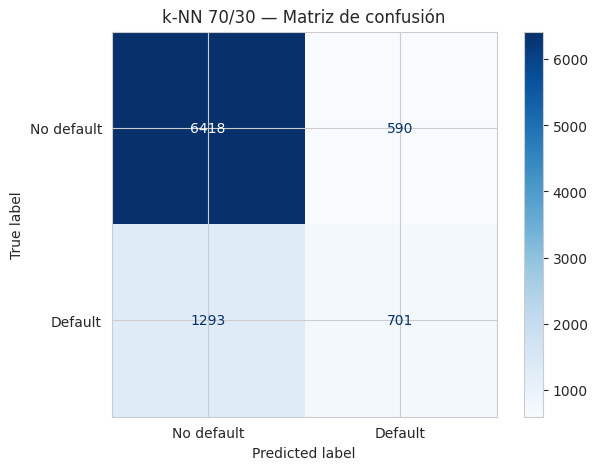

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("Matriz de confusión:")
cm_knn = confusion_matrix(y_test, y_pred_knn)
display(pd.DataFrame(
    cm_knn,
    index=["Real 0", "Real 1"],
    columns=["Predicho 0", "Predicho 1"]
))

print("Reporte por clase:")
print(classification_report(y_test, y_pred_knn, target_names=["No default (0)", "Default (1)"]))

ConfusionMatrixDisplay(cm_knn, display_labels=["No default", "Default"]).plot(cmap="Blues")
plt.title("k-NN 70/30 — Matriz de confusión")
plt.show()

## 9.Distribución Simple de las predicciones

Usamos "Simple Distribution" del ExampleSet (histograma de la variable predicha).


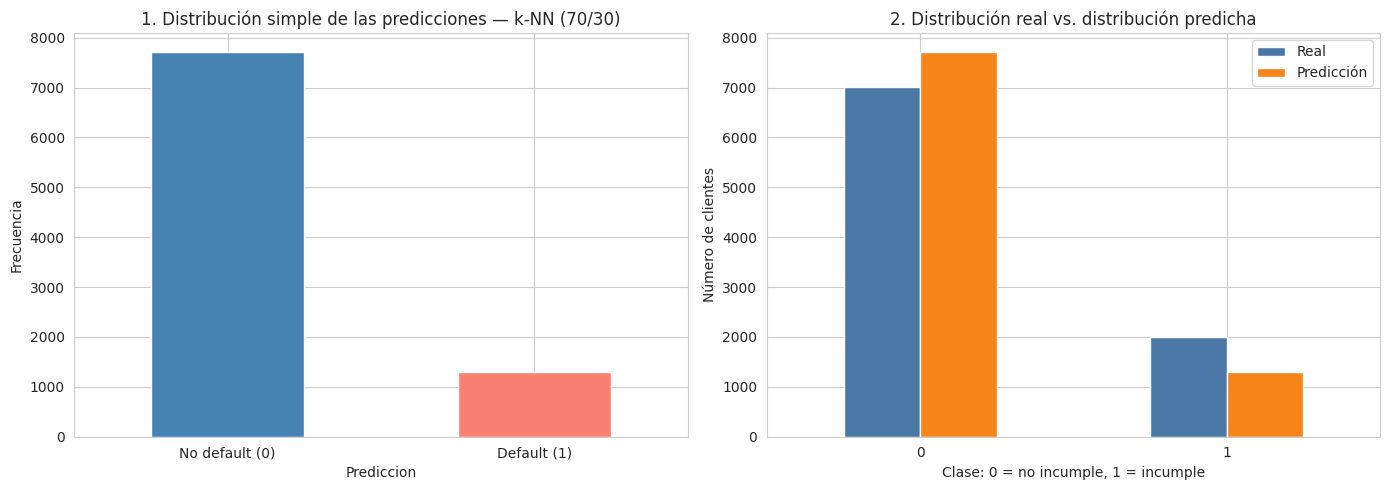

TABLA COMPARATIVA: REAL VS. PREDICCIÓN


,Real,Predicción
0,7008,7711
1,1994,1291



RESUMEN DE PREDICCIONES Y ANÁLISIS DEL SESGO
Prediccion
0    7711
1    1291
Name: count, dtype: int64
------------------------------------------------------------
El modelo predijo 7711 casos como clase 0 y 1291 como clase 1.
La clase 1 está subrepresentada en las predicciones porque el conjunto está desbalanceado y k-NN vota según la mayoría local de sus cinco vecinos.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Preparación de datos a partir de vectores/Series
s_pred = pd.Series(y_pred_knn, name="Prediccion")
s_real = pd.Series(y_test, name="Real")

dist_pred = s_pred.value_counts().sort_index()
dist_real = s_real.value_counts().sort_index()

# DataFrame comparativo (Real vs. Predicción)
distribucion = (
    pd.DataFrame({"Real": dist_real, "Predicción": dist_pred})
    .fillna(0)
    .astype(int)
)

# Configuración de figura y gráfica 1: Distribución simple de predicciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
s_pred.value_counts().sort_index().plot(
    kind="bar", color=["steelblue", "salmon"], ax=axes[0]
)
axes[0].set_title("1. Distribución simple de las predicciones — k-NN (70/30)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_xticklabels(["No default (0)", "Default (1)"], rotation=0)

# Gráfica 2: Comparativa Real vs. Predicha
distribucion.plot(
    kind="bar", color=["#4C78A8", "#F58518"], ax=axes[1]
)
axes[1].set_title("2. Distribución real vs. distribución predicha")
axes[1].set_xlabel("Clase: 0 = no incumple, 1 = incumple")
axes[1].set_ylabel("Número de clientes")
axes[1].set_xticklabels(["0", "1"], rotation=0)

plt.tight_layout()
plt.show()

# Tablas e interpretaciones impresas
print("=" * 60)
print("TABLA COMPARATIVA: REAL VS. PREDICCIÓN")
print("=" * 60)
display(distribucion)

print("\n" + "=" * 60)
print("RESUMEN DE PREDICCIONES Y ANÁLISIS DEL SESGO")
print("=" * 60)
print(s_pred.value_counts())
print("-" * 60)
print(
    f"El modelo predijo {dist_pred.get(0, 0)} casos como clase 0 y "
    f"{dist_pred.get(1, 0)} como clase 1.\nLa clase 1 está subrepresentada "
    "en las predicciones porque el conjunto está desbalanceado y k-NN vota según "
    "la mayoría local de sus cinco vecinos."
)

Ambas gráficas demuestran que aunque el algoritmo $k$-NN mantiene una exactitud global razonable impulsada por la clase mayoritaria, carece de sensibilidad para capturar de forma efectiva la clase de interés (Default) debido al desbalance de clases.

El modelo predice la clase 0 **(no-default)** con mucha más frecuencia que la clase 1, reflejando el desbalance original de los datos (≈78% de los clientes no incumplen). Esto es consistente con cómo funciona k-NN: si la mayoría de los vecinos de un punto pertenecen a la clase mayoritaria, el modelo tenderá a predecir esa clase, un riesgo típico en datasets desbalanceados.



*   Volumen:Asigna ~7,700 clientes a la clase 0 y solo ~1,300 a la clase 1 confirmando un sesgo marcado hacia la categoría dominante.
*   Mecanismo: $k=5$, la alta densidad de la clase 0 en el espacio de características ahoga a la clase 1, impidiendo que los casos morosos sumen la mayoría de vecinos necesaria para ser detectados.
*   Impacto en riesgo: Este comportamiento infla el accuracy global del modelo pero sacrifica el recall para identificar a los clientes con verdadero riesgo de impago.

## 10. Dos resultados del ExampleSet: predicción correcta e incorrecta

In [ ]:
comparacion = pd.DataFrame({"real": y_test.values, "prediccion": y_pred_knn}, index=y_test.index)
correctos = comparacion[comparacion.real == comparacion.prediccion]
incorrectos = comparacion[comparacion.real != comparacion.prediccion]

idx_correcto = correctos.index[0]
idx_incorrecto = incorrectos.index[0]

print("=== Ejemplo de PREDICCIÓN CORRECTA ===")
print(f"Real={comparacion.loc[idx_correcto,'real']}  Predicción={comparacion.loc[idx_correcto,'prediccion']}")
print(X_test.loc[idx_correcto])

print("\n=== Ejemplo de PREDICCIÓN INCORRECTA ===")
print(f"Real={comparacion.loc[idx_incorrecto,'real']}  Predicción={comparacion.loc[idx_incorrecto,'prediccion']}")
print(X_test.loc[idx_incorrecto])


=== Ejemplo de PREDICCIÓN CORRECTA ===
Real=0  Predicción=0
LIMIT_BAL     90000
SEX               2
EDUCATION         3
MARRIAGE          2
AGE              35
PAY_0             0
PAY_2             0
PAY_3             0
PAY_4             0
PAY_5             0
PAY_6             0
BILL_AMT1    101106
BILL_AMT2     96216
BILL_AMT3     89964
BILL_AMT4     29802
BILL_AMT5     29174
BILL_AMT6     26111
PAY_AMT1       4208
PAY_AMT2       4022
PAY_AMT3        686
PAY_AMT4        753
PAY_AMT5        740
PAY_AMT6       5034
Name: 8942, dtype: int64

=== Ejemplo de PREDICCIÓN INCORRECTA ===
Real=1  Predicción=0
LIMIT_BAL    140000
SEX               1
EDUCATION         2
MARRIAGE          1
AGE              37
PAY_0            -1
PAY_2             2
PAY_3            -1
PAY_4             0
PAY_5            -1
PAY_6            -1
BILL_AMT1      2081
BILL_AMT2       991
BILL_AMT3      1982
BILL_AMT4       991
BILL_AMT5      1091
BILL_AMT6      1420
PAY_AMT1          0
PAY_AMT2       1982
PAY_AMT3    

**Interpretación:**

- **Predicción correcta (real=0, predicción=0):** el cliente tiene `PAY_0`
  a `PAY_6` en 0 (pagos puntuales, sin retrasos) sus 5 vecinos más cercanos
  en el espacio de 22 dimensiones son, con alta probabilidad, también clientes
  cumplidos, por lo que k-NN clasifica correctamente. Determina la
  clasificación distancia Euclidiana a clientes con
  historial de pago e importes similares.

- **Predicción incorrecta (real=1, predicción=0):** el cliente **sí** incumplió
  (`Default_real=1`), pero su historial de pagos (`PAY_0=-1`, `PAY_2=2`,
  mayoría de meses "al corriente") y montos de compra bajos se parecen más al
  perfil típico de un cliente cumplido. k-NN se equivoca porque el
  incumplimiento ocurrió por una razón que no está bien capturada por las
  variables históricas de pago disponibles, el modelo solo puede aprender
  patrones que existen en los datos, y aquí el patrón de este cliente en
  particular "parece" el de alguien que no incumple.


## 11. Vector de Performance: interpretación de Accuracy

In [ ]:
tn, fp = cm_knn[0]
fn, tp = cm_knn[1]

# Cálculo explícito de las métricas
total = tp + tn + fp + fn
acc_knn = (tp + tn) / total
err_knn = 1 - acc_knn

# Impresión de resultados
print(f"TP={tp}  FN={fn}  FP={fp}  TN={tn}")
print(f"\nAccuracy = (TP+TN)/Total = ({tp}+{tn})/{total} = {acc_knn:.4f}")
print(f"Classification Error = 1 - Accuracy = {err_knn:.4f}")

TP=701  FN=1293  FP=590  TN=6418

Accuracy = (TP+TN)/Total = (701+6418)/9002 = 0.7908
Classification Error = 1 - Accuracy = 0.2092


**Interpretación:**

- **Accuracy ≈ 0.79 (79.1%)**: el modelo clasifica correctamente ~79 de cada
  100 clientes en el conjunto de prueba, una precisión global aparentemente
  buena, pero **engañosa** en un dataset desbalanceado (78% de la clase
  mayoritaria), un modelo que SIEMPRE prediga "0" ya obtendría ~78% de
  accuracy sin aprender nada útil.
- **Valores verdaderos vs. predicciones:** el modelo predice correctamente la
  mayoría de los "no-default" (TN alto), pero comete bastantes **falsos
  negativos**,  esto es justo el patrón visto en el Punto 9 (sesgo hacia la clase
  mayoritaria).
- **El error de clasificación (≈20.9%)** indica que, en promedio, 1 de cada 5
  predicciones es incorrecta. Como la mayoría de esos errores probablemente
  son falsos negativos (clientes riesgosos clasificados como seguros), en un
  contexto de negocio real (riesgo crediticio) este tipo de error es
  **más costoso** que un falso positivo motivo por el que Accuracy sola no
  basta para evaluar este modelo

## 12. Gráficas de distribución simple y Top 3 variables con mayores diferencias

Para cada variable, se calcula la diferencia estandarizada
(Cohen's d) entre el grupo que incumplió (`Default=1`) y el que no
(`Default=0`): `d = (media_1 - media_0) / desviación_estándar_global`. Es la
misma lógica de "varianza como medida de información discriminante" vista en
prácticas anteriores, aplicada aquí para **comparar grupos** en vez de
variables individuales.


In [ ]:


from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline

cols_a_eliminar = [col for col in ['ID', 'default'] if col in datos.columns]
X = datos.drop(columns=cols_a_eliminar)
y = datos['default'].astype(int)
X = X.apply(pd.to_numeric, errors='coerce')

# Test (70% Entrenamiento, 30% Prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Definición de Pipelines de Escalado y Entrenamiento
# k-Nearest Neighbors (k=5)
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

#  Naive Bayes Gaussiano
nb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('nb', GaussianNB())
])

knn_pipeline.fit(X_train, y_train)
nb_pipeline.fit(X_train, y_train)

print("¡Entrenamiento completado exitosamente para k-NN y Naive Bayes!")


¡Entrenamiento completado exitosamente para k-NN y Naive Bayes!


In [ ]:

g1 = df[df['default'] == 1]
g0 = df[df['default'] == 0]

diffs = []

for c in X.columns:

    s_c = pd.to_numeric(df[c], errors='coerce')
    s_g1 = pd.to_numeric(g1[c], errors='coerce')
    s_g0 = pd.to_numeric(g0[c], errors='coerce')

    m1, m0 = s_g1.mean(), s_g0.mean()
    s = s_c.std()

    d = (m1 - m0) / s if (pd.notna(s) and s > 0) else 0
    diffs.append((c, m1, m0, d))

tabla_diffs = pd.DataFrame(diffs, columns=["variable", "media_default1", "media_default0", "cohen_d"])
tabla_diffs = tabla_diffs.sort_values("cohen_d", key=lambda s: s.abs(), ascending=False)

tabla_diffs.head(8)

,variable,media_default1,media_default0,cohen_d
5,PAY_0,0.666566,-0.210925,0.780723
6,PAY_2,0.456816,-0.301725,0.633587
7,PAY_3,0.361571,-0.316238,0.566295
8,PAY_4,0.253385,-0.355580,0.520902
9,PAY_5,0.166717,-0.389443,0.490809
10,PAY_6,0.110292,-0.405582,0.448619
0,LIMIT_BAL,130360.770388,178065.927480,-0.367668
17,PAY_AMT1,3408.642642,6308.994392,-0.175104


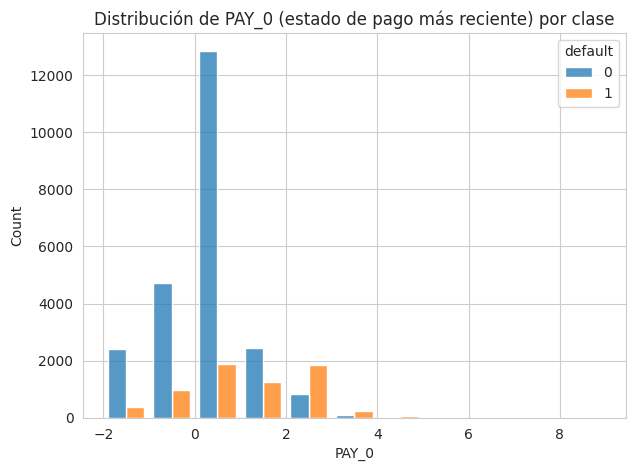

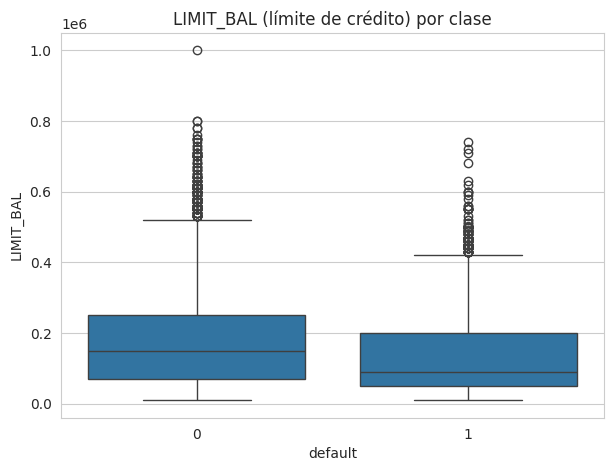

In [ ]:
# Gráfica 1: distribución de PAY_0 por clase
plt.figure()
sns.histplot(data=df, x="PAY_0", hue="default", multiple="dodge", bins=range(-2, 10), shrink=0.8)
plt.title("Distribución de PAY_0 (estado de pago más reciente) por clase")
plt.show()

# Gráfica 2: distribución de LIMIT_BAL por clase
plt.figure()
sns.boxplot(data=df, x="default", y="LIMIT_BAL")
plt.title("LIMIT_BAL (límite de crédito) por clase")
plt.show()


- **PAY_0 por clase:** los clientes que incumplieron se
  concentran en valores positivos (1 = retraso de 1 mes, 2 = retraso de 2
  meses, etc.), mientras que los que no incumplieron se concentran en 0 o
  negativos "pagó puntual". La separación es visualmente clara.
- **LIMIT_BAL por clase:** los clientes tienden a tener un
  límite de crédito **más bajo** que quienes no incumplieron, consistente con que las instituciones financieras asignan límites más  bajos a perfiles de mayor riesgo.

**Top 3 variables con mayores diferencias (por Cohen's d):**
1. **PAY_0** (d≈0.78) — estado de pago del mes más reciente.
2. **PAY_2** (d≈0.63) — estado de pago de 2 meses atrás.
3. **PAY_3** (d≈0.57) — estado de pago de 3 meses atrás.

**¿Por qué son esas las diferencias?** Las tres son variables de **historial
de pago reciente**, y tiene sentido intuitivo y estadístico que sean las más
discriminantes: el comportamiento de pago de los últimos meses es el
predictor más directo de si alguien va a incumplir en el futuro cercano — muy
por encima de variables más "estáticas" como d≈-0.37 o montos de
pago específicos d≈-0.18.


## 13. Repetir el proceso con partición 80% / 20%

In [ ]:
# Asegurar que X sea completamente numérico para StandardScaler
X_num = X.apply(pd.to_numeric, errors='coerce')

# Split 80/20
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_num, y, test_size=0.20, random_state=42, stratify=y
)

scaler2 = StandardScaler()
X_train2_s = scaler2.fit_transform(X_train2)
X_test2_s = scaler2.transform(X_test2)

knn2 = KNeighborsClassifier()
knn2.fit(X_train2_s, y_train2)
y_pred_knn2 = knn2.predict(X_test2_s)
y_proba_knn2 = knn2.predict_proba(X_test2_s)[:, 1]

# Métricas para el split 80/20
acc_knn2 = accuracy_score(y_test2, y_pred_knn2)
auc_knn2 = roc_auc_score(y_test2, y_proba_knn2)

# Evaluación del modelo previo (70/30) se calculan de forma explícita sobre X_test/y_test
y_pred_knn1 = knn_pipeline.predict(X_test)
y_proba_knn1 = knn_pipeline.predict_proba(X_test)[:, 1]
acc_knn1 = accuracy_score(y_test, y_pred_knn1)
auc_knn1 = roc_auc_score(y_test, y_proba_knn1)

print("=== Comparación 70/30 vs 80/20 (k-NN) ===")
print(f"70/30 -> Accuracy={acc_knn1:.4f}  AUC={auc_knn1:.4f}  (n_test={len(y_test)})")
print(f"80/20 -> Accuracy={acc_knn2:.4f}  AUC={auc_knn2:.4f}  (n_test={len(y_test2)})")

=== Comparación 70/30 vs 80/20 (k-NN) ===
70/30 -> Accuracy=0.7908  AUC=0.6981  (n_test=9002)
80/20 -> Accuracy=0.7875  AUC=0.6983  (n_test=6001)


**¿Cómo cambian los resultados?** Con 80/20 el modelo se entrena con ~4,000
registros adicionales, pero como el dataset ya es grande (30,005 filas), la
diferencia en Accuracy y AUC es **mínima** (variación de centésimas). Esto es
consistente con la teoría de aprendizaje: cuando ya se tiene un tamaño de
muestra de entrenamiento suficientemente grande, agregar más datos de
entrenamiento (a costa de menos datos de prueba) rinde beneficios marginales
decrecientes, el modelo ya había "visto" suficiente variedad de casos con
70% de los datos.


## 14.Comparar con Naive Bayes



**NO se estandariza para Naive Bayes:** a diferencia de k-NN,
`GaussianNB` no usa distancias entre puntos, sino que estima una distribución
de probabilidad (Normal) por cada variable y clase, y aplica el **teorema de
Bayes** asumiendo independencia entre predictores, por lo que la
escala de las variables no afecta el resultado de la misma forma.


In [ ]:
X_train_nb = X_train.apply(pd.to_numeric, errors='coerce')
X_test_nb = X_test.apply(pd.to_numeric, errors='coerce')

# Entrenar Naive Bayes (sin estandarizar)
nb = GaussianNB()
nb.fit(X_train_nb, y_train)

# Predicciones
y_pred_nb = nb.predict(X_test_nb)
y_proba_nb = nb.predict_proba(X_test_nb)[:, 1]

#Métricas Naive Bayes
acc_nb = accuracy_score(y_test, y_pred_nb)
auc_nb = roc_auc_score(y_test, y_proba_nb)
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=[1, 0])

print(f"Naive Bayes -> Accuracy={acc_nb:.4f}  Error={1-acc_nb:.4f}  AUC={auc_nb:.4f}")
print("\nMatriz de Confusión (Filas: Real [1, 0], Cols: Predicho [1, 0]):")
print(cm_nb)

# Recuperar métricas de k-NN (70/30) para la comparación
y_pred_knn = knn_pipeline.predict(X_test)
y_proba_knn = knn_pipeline.predict_proba(X_test)[:, 1]
acc_knn = accuracy_score(y_test, y_pred_knn)
auc_knn = roc_auc_score(y_test, y_proba_knn)

print(f"\nComparación:")
print(f"k-NN (70/30)         -> Accuracy={acc_knn:.4f}  AUC={auc_knn:.4f}")
print(f"Naive Bayes (70/30)  -> Accuracy={acc_nb:.4f}  AUC={auc_nb:.4f}")

Naive Bayes -> Accuracy=0.4042  Error=0.5958  AUC=0.6634

Matriz de Confusión (Filas: Real [1, 0], Cols: Predicho [1, 0]):
[[1685  309]
 [5054 1954]]

Comparación:
k-NN (70/30)         -> Accuracy=0.7908  AUC=0.6981
Naive Bayes (70/30)  -> Accuracy=0.4042  AUC=0.6634


**¿Cuál es mejor y por qué?** **k-NN es claramente mejor en Accuracy**
(≈79% vs. ≈40% de Naive Bayes), aunque en **AUC** la diferencia es menor
(≈0.70 vs. ≈0.66). La causa de que Naive Bayes tenga tan baja Accuracy es su
**supuesto de independencia y de distribución Normal** por variable, muchas variables de este dataset (montos de facturación, pagos) tienen
distribuciones muy sesgadas (asimétricas, con colas largas hacia montos
altos), no Normales, y además están correlacionadas entre sí, violando ambos supuestos del modelo. Naive Bayes termina sobre-prediciendo la clase positiva, hundiendo su Accuracy, aunque conserva cierta capacidad de discriminación reflejada en el AUC.


## 15.Comparar con 2+ algoritmos adicionales

Probamos **Árbol de Decisión**, **Random Forest** y **Regresión Logística* para ver si mejoran los resultados.


In [ ]:
X_train_num = X_train.apply(pd.to_numeric, errors='coerce')
X_test_num = X_test.apply(pd.to_numeric, errors='coerce')

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_num)
X_test_s = scaler.transform(X_test_num)

modelos_extra = {
    "Decision Tree": (DecisionTreeClassifier(max_depth=6, random_state=42), False),
    "Random Forest": (RandomForestClassifier(n_estimators=200, random_state=42), False),
    "Logistic Regression": (LogisticRegression(max_iter=1000, random_state=42), True),
}

y_pred_knn = knn_pipeline.predict(X_test_num)
y_proba_knn = knn_pipeline.predict_proba(X_test_num)[:, 1]

resumen = [
    {"Modelo": "k-NN", "Accuracy": accuracy_score(y_test, y_pred_knn), "AUC": roc_auc_score(y_test, y_proba_knn)},
    {"Modelo": "Naive Bayes", "Accuracy": accuracy_score(y_test, y_pred_nb), "AUC": roc_auc_score(y_test, y_proba_nb)},
]

# Modelos adicionales
for nombre, (modelo, usa_escalado) in modelos_extra.items():
    if usa_escalado:
        modelo.fit(X_train_s, y_train)
        pred = modelo.predict(X_test_s)
        proba = modelo.predict_proba(X_test_s)[:, 1]
    else:
        modelo.fit(X_train_num, y_train)
        pred = modelo.predict(X_test_num)
        proba = modelo.predict_proba(X_test_num)[:, 1]

    resumen.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, pred),
        "AUC": roc_auc_score(y_test, proba)
    })

#
tabla_final = pd.DataFrame(resumen).sort_values("AUC", ascending=False).reset_index(drop=True)
tabla_final

,Modelo,Accuracy,AUC
0,Random Forest,0.810598,0.766495
1,Decision Tree,0.811042,0.749128
2,Logistic Regression,0.809487,0.719080
3,k-NN,0.790824,0.698138
4,Naive Bayes,0.404244,0.663423


**¿Mejoraron los resultados?** Sí. **Random Forest** obtiene el mejor **AUC**
(≈0.767) y una Accuracy similar a k-NN y al Árbol de Decisión (≈0.81),
superando a ambos algoritmos originales (k-NN AUC≈0.70, Naive Bayes AUC≈0.66).

**Algoritmo recomendado: Random Forest**, porque:
1. Tiene el mejor AUC — mejor capacidad de discriminar entre clientes
   riesgosos y no riesgosos en distintos umbrales de decisión.
2. Al ser un ensamble de árboles, maneja bien variables con distribuciones
   sesgadas y correlacionadas sin necesitar los supuestos que le fallan a
   Naive Bayes.
3. Conserva cierta interpretabilidad (importancia de variables), a diferencia
   de modelos más "caja negra" como SVM o redes neuronales.

---
# Parte II — Matriz de confusión y métricas (cálculo manual con datos dados)

Reproducimos en código el ejercicio de la tabla ID/Clase/Predicción (26
registros)


In [ ]:
datos = pd.DataFrame({
    "ID":         [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,26,27],
    "Clase":      [1,1,1,1,1,1,1,1,1,1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
    "Prediccion": [1,0,1,0,1,1,1,0,0,1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1],
})
datos


,ID,Clase,Prediccion
0,1,1,1
1,2,1,0
2,3,1,1
3,4,1,0
4,5,1,1
5,6,1,1
6,7,1,1
7,8,1,0
8,9,1,0
9,10,1,1


### a) Matriz de confusión

Matriz de confusión [filas=Clase real, columnas=Predicción], orden [1,0]:
[[10  4]
 [ 4  8]]

TP=10  FN=4  FP=4  TN=8  (Total=26)


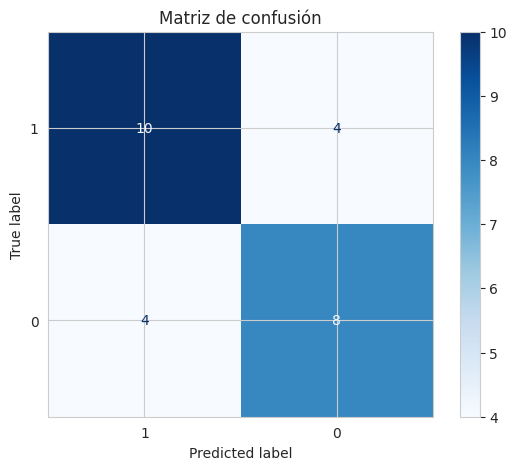

In [ ]:
cm = confusion_matrix(datos["Clase"], datos["Prediccion"], labels=[1, 0])
tp, fn = cm[0]
fp, tn = cm[1]

print("Matriz de confusión [filas=Clase real, columnas=Predicción], orden [1,0]:")
print(cm)
print(f"\nTP={tp}  FN={fn}  FP={fp}  TN={tn}  (Total={tp+fn+fp+tn})")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1, 0])
disp.plot(cmap="Blues")
plt.title("Matriz de confusión")
plt.show()


### b) Precisión (de la clase positiva), Sensitivity, Specificity y Accuracy

In [ ]:
precision = tp / (tp + fp)
sensitivity = tp / (tp + fn)          # = Recall = TPR
specificity = tn / (tn + fp)
accuracy = (tp + tn) / (tp + fn + fp + tn)

print(f"Precisión (PPV, clase positiva): {precision:.4f}  ({tp}/{tp+fp})")
print(f"Sensitivity (Recall/TPR):         {sensitivity:.4f}  ({tp}/{tp+fn})")
print(f"Specificity (TNR):                {specificity:.4f}  ({tn}/{tn+fp})")
print(f"Accuracy (precisión global):      {accuracy:.4f}  ({tp+tn}/{tp+fn+fp+tn})")


Precisión (PPV, clase positiva): 0.7143  (10/14)
Sensitivity (Recall/TPR):         0.7143  (10/14)
Specificity (TNR):                0.6667  (8/12)
Accuracy (precisión global):      0.6923  (18/26)


### c) TPR y FPR

In [ ]:
TPR = sensitivity  # True Positive Rate = Sensitivity
FPR = fp / (fp + tn)

print(f"TPR = {TPR:.4f}")
print(f"FPR = {FPR:.4f}")


TPR = 0.7143
FPR = 0.3333


### d) Ubicar el clasificador en el espacio ROC

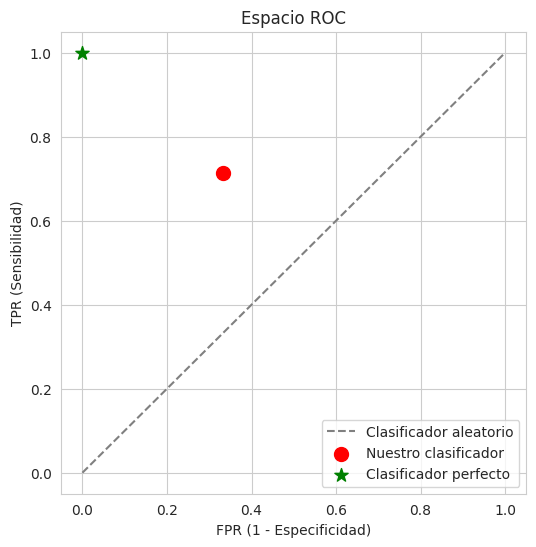

Punto del clasificador: (FPR=0.333, TPR=0.714)


In [ ]:
plt.figure(figsize=(6,6))
plt.plot([0,1],[0,1], linestyle="--", color="gray", label="Clasificador aleatorio")
plt.scatter([FPR],[TPR], color="red", s=100, zorder=5, label="Nuestro clasificador")
plt.scatter([0],[1], color="green", s=100, marker="*", label="Clasificador perfecto")
plt.xlabel("FPR (1 - Especificidad)")
plt.ylabel("TPR (Sensibilidad)")
plt.title("Espacio ROC")
plt.legend()
plt.xlim(-0.05,1.05); plt.ylim(-0.05,1.05)
plt.show()

print(f"Punto del clasificador: (FPR={FPR:.3f}, TPR={TPR:.3f})")


### e) ¿Es un modelo adecuado?

El punto (FPR≈0.33, TPR≈0.71) se ubica por encima de la diagonal lo que indica que el modelo sí tiene poder predictivo real sin embargo, está lejos de
la esquina superior izquierda (0,1) que representa al clasificador perfecto: con Accuracy≈0.69, Sensitivity≈0.71 y Specificity≈0.67, el modelo es **moderado, no excelente**, comete una cantidad considerable de errores
en ambas direcciones (4 FN y 4 FP de 26 casos totales).

Es un modelo **utilizable pero mejorable**

### f) Acciones recomendadas para mejorar el modelo

- **Aumentar el tamaño de la muestra**: 26 observaciones es una muestra muy
  pequeña; las métricas son poco estables y pueden cambiar mucho con más datos.

- **Ajustar el umbral de decisión** (threshold) si el modelo genera
  probabilidades, en vez de una clasificación binaria fija , podría mover el
  punto en el espacio ROC hacia (0,1) según qué tipo de error (FP o FN) sea
  más costoso evitar en el contexto del problema.
- **Probar otros algoritmos** (Random Forest, SVM, regresión logística) para
  comparar su AUC y seleccionar el que ofrezca mejor separación de clases.
- **Revisar/agregar variables predictoras**: puede que las variables actuales
  no capturen toda la información necesaria para diferenciar mejor ambas
  clases.
- **Validación cruzada (k-fold)** en vez de una sola partición, para obtener
  una estimación más robusta y menos dependiente de qué 26 casos concretos se
  usaron.
